In [95]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:80% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.output {font-size:10pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:10pt;padding:2px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="green">ch10. N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [NUMPY](https://numpy.org)
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)

# 1절. 넘파이 패키지

In [3]:
import numpy as np
np.__version__ # tensorflow == 2.10과 맞는 numpy 버전

'1.23.5'

In [5]:
# np.arange(from, stop, by) : form부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성


In [21]:
from numpy import arange
a = arange(15, 
           # dtpye=np.int32
          ).reshape(3, 5) # 3행 5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [13]:
# a 변수의 타입을 물어본 것
type(a)

numpy.ndarray

In [14]:
# a 배열의 요소들의 type
a.dtype 

dtype('int32')

In [16]:
a.dtype.name

'int32'

In [17]:
a.itemsize # 한 요소(item)의 bytesize

4

In [18]:
a.ndim # 축수(차원수)

2

In [19]:
a.size # 배열 요소의 갯수

15

In [15]:
# 배열 구조(1차원 15열)
a.shape

(3, 5)

In [24]:
print('shape 조정전 a:\n', a)
a.shape = (5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경


In [25]:
# 배열 요소의 타입변경(X)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [26]:
a.size # 요소갯수

12

In [27]:
a.dtype # 저장되어 있는 것을 32bit씩 읽겠다.

dtype('int32')

In [28]:
a.itemsize # 요소의 byte수

4

In [29]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [30]:
a.itemsize 

8

### 배열 요소의 타입변경


In [31]:
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [32]:
a.astype(np.int64) # 출력 0 -> a가 바뀌지 않음 / 출력 x -> a 바뀜.

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [35]:
a.dtype

dtype('int32')

In [36]:
a.itemsize

4

In [37]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [38]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.3 배열 저장
- pkl(객체저장, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [68]:
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [69]:
%%time
import time
start = time.time() # 1970.01.01부터 지금까지의 초수
import pickle
with open('Data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

실행 시간 : 0.001444101333618164
CPU times: total: 0 ns
Wall time: 1.44 ms


In [70]:
%%time
with open('Data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 15.6 ms
Wall time: 36.9 ms


In [71]:
# a ==(파일 저장)==> 피클파일(269B) ==(load)==> loaded_a
loaded_a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [72]:
%%time
np.save('Data/ch11.npy', a) # 넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 2 ms


In [73]:
%%time
loaded_a2 = np.load('Data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 15.9 ms


In [74]:
# a ==(저장)==> npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

# 2절. 넘파이 배열 

- array() 함수를 이용한 다른 파이썬 데이터 구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성 함수 : arange, ones, zeros, full, empty .....
- 랜덤값을 갖는 배열 생성함수...
- [넘파이 함수들](https://numpy.org/doc/stable/reference/index.html)

## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F) \
type 예 : int16, int32, float16, float32, float64....

In [57]:
a = np.array([2, 14, 6]
            # dtype=np.int16
            )# 정수의 기본 타입은 int32 / 실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [58]:
a[0], a[1], a[2]

(2, 14, 6)

In [59]:
for item in a:
    print(item, end='\t')

2	14	6	

In [61]:
b = np.array([[1.5, 2.3],  # 동일 자료형의 집합으로 배열 생성: 정수>실수>문자
            [4, 5]])       # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [76]:
b.dtype

dtype('float64')

In [78]:
l = [[1.5, 2.3], [4, 5]]
l[0][1]

2.3

In [63]:
b[0,1] # 2차원 [axis0=행, axis0=열] cf. 1차원[axis0=열]

2.3

In [75]:
a = np.array([[1.5, 2.3], 
              [4, 5]], dtype=np.float32)
a.dtype

dtype('float32')

In [81]:
# a의 배열 구조 변경
a.shape = (2, 2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [82]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [84]:
l = [[1.5, 2.3], 
              [4, 5]]
for row in l :
    for item in row:
        print(item, end=' ')
        print()

1.5 
2.3 
4 
5 


In [86]:
for i, row in enumerate(a) :
    for j, item in enumerate(row):
        # print(f"{i}행{j}열 : {a[i][j]}", end='\t')
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


### 인덱싱(Indexing)
 : 색인, 목차, 지표 (찾아보기) \
" 데이터가 일렬로 늘어서 있을 때, 각 데이터에 매겨진 '위치 번호(주소)'를 사용해 원하는 것만 콕 집어내는 작업"
- print(b[0,2])없는 인덱싱은 에러

In [87]:
print(b[0,0])
print()

1.5



### 슬라이싱
- from : stop :  \
  from부터 stop전까지 by씩 전진. 인덱싱은 음수
  
- 0~끝행, 1열부터 끝열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

In [88]:
b[0:, -1]

array([2.3, 5. ])

In [89]:
b[0, 1:3] # 0행, 1열부터 3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

#### ex1 ) 모든 행의 마지막 열만 추출
```
b = np.arrary([[1, 2, 3,]
               [6, 7, 8]])
```

In [90]:
b = np.array([[1, 2, 3],
              [6, 7, 8]])
b

array([[1, 2, 3],
       [6, 7, 8]])

In [99]:
b[:, -1]

array([3, 8])

#### ex2 ) 모든 행의 마지막 열을 제외한 부분 추출

In [98]:
b[0:2, 0:2]

array([[1, 2],
       [6, 7]])

In [103]:
# copy 사용
# 스칼라 변수
a = 10  #원본
b = a  #복제본
print("a={}, b={}, a주소={}, b주소{}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소{}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=2570225975824, b주소2570225975824
a=10, b=-1, a주소=2570225975824, b주소2570225975472


#### # numpy 배열

In [111]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # dtype="int16"==dtype.int16  / dtype=np.uint16_음수가 안나온다나?
d = np.array(c, copy=False)# d = c # 할당하기
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570385650480 2570385650480
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570385650480 2570385650480


In [112]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8)
d = np.array(c, copy=True) # d = c.copy()와 동일 # 깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570385638768 2570385645488
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570385638768 2570385645488


#### # copy = False해도 깊은 복사가 되는 경우
- dtype이 바뀌면 자동으로 깊은 복사가 됨.

In [113]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8)
d = np.array(c, copy=False, dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570386457296 2570386457200
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570386457296 2570386457200


## 2.2 기본값이 있는 배열 만들기

- np.zeros( tup [, dtype] ) : 요소들이 다 0.0
- np.ones( tup [, dtype] ) : 요소들이 다 1.0
- np.full( tup, 기본값 ) : 요소들이 다 두 번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용을 임의의 값인 배열(메모리 상태에 따라 달라짐

**※위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음**

#### # zeros

In [148]:
np.zeros((3,5)) # 3행 5열짜리 2차원 Float64 배열(요소들은 다 0)
np.zeros((5,)) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros(5) # 5열짜리 1차원 float64 배열 (요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [151]:
x = np.zeros( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


####  # ones

In [152]:
np.ones((3,5)) # 3행 5열짜리 2차원 Float64 배열(요소들은 다 1)
np.ones((5,)) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones(5) # 5열짜리 1차원 float64 배열 (요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [153]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


####  # full

In [155]:
x = np.full( (2, 5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


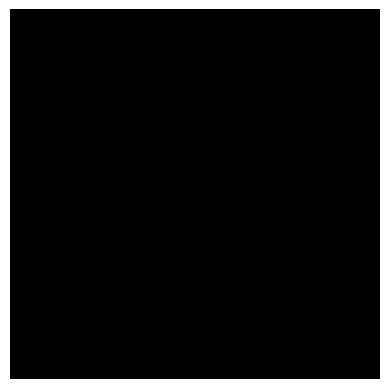

In [170]:
# 이미지 만들기
import matplotlib.pyplot as plt
img = np.full( (28, 28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28, 28), 200, dtype=np.uint8) #회색
img = np.zeros( (28, 28), dtype=np.uint8) # 검정색
# plt.figure(figsize)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [174]:
import numpy as np
np.empty((3,2))

array([[  0.,   0.],
       [  0., 480.],
       [640.,   0.]])

##  2.3 랜더값을 갖는 배열 만들기

※ n차원 배열 만들기

- np.random.random(tup) : 0부터 1미만의 균등분포를 갖은 tuo사이즈 랜덤값
- np.random.unifom(low=0, high=1.0, sizw=tup): low부터 high미만까지 균등분포를 갖는 랜덤값

- np.random.normal(loc=0.0, scale-1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜더값 ★가장 많이 사용되는 식★
----

```
표준편차(기초통계)


```

※ 1차원 배열 만들기
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포(평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n개)

----

※ 난수 1개 만들기
- np.random.randint(n) : 0부터 n미만의 정수 난수 1개 발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from 부터 to미만의 정수 난수 1개 발생
                                == random.randint(from, to-1)

In [175]:
np.random.random((2,3))

array([[0.0028145 , 0.27297698, 0.23767735],
       [0.31396309, 0.13008799, 0.91678204]])

In [177]:
np.random.rand(10000)

array([0.80690307, 0.83078561, 0.13799112, ..., 0.28957734, 0.42194557,
       0.58080443])

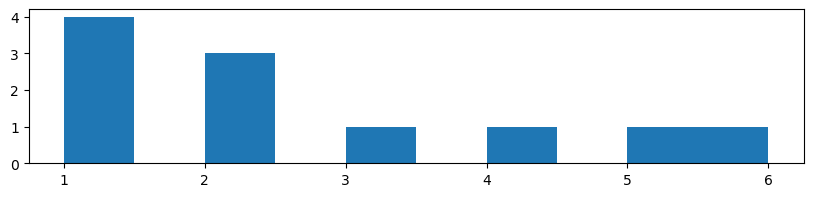

In [183]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 1, 1, 2, 2, 1, 2, 3, 4, 5, 6]
plt.hist(x, bins=10)
plt.show()

###  # 균등분포

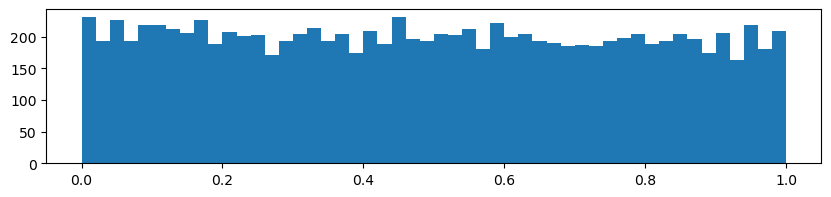

In [195]:
# 균등분포
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.random(100000)
# print(x)
# x = np.random.uniform(1, 10, 10)
x = np.random.rand(10000)
plt.hist(x, bins=50)
plt.show()

### # 정규분포

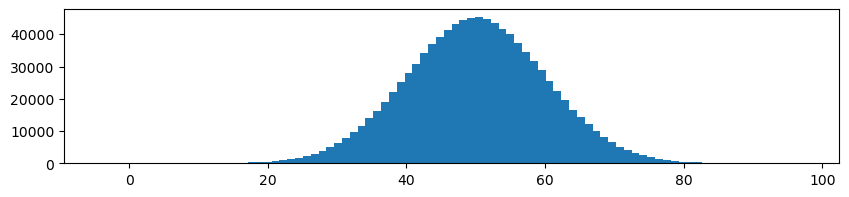

In [202]:
# 정규분포
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000)
plt.hist(x, bins=90)
plt.show()

###  # 표준정규분포

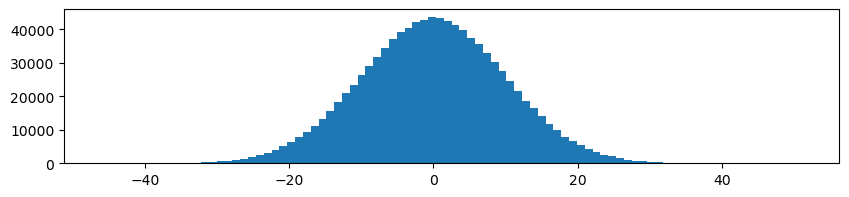

In [201]:
# 표준정규분포 1
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(0, 10, 1000000)
plt.hist(x, bins=90)
plt.show()

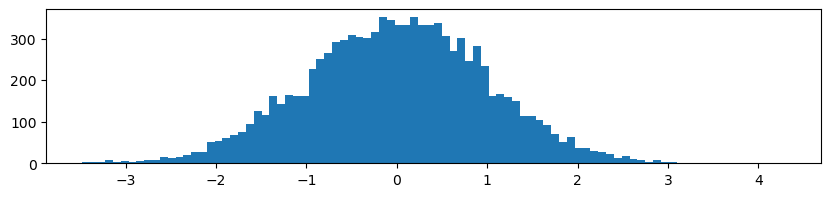

In [205]:
# 표준정규분포 2
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.randn(10000)
plt.hist(x, bins=90)
plt.show()

###  # 2차원 균등분포 난수(0~1미만 실수 난수) 배열

In [3]:
import numpy as np
# np.random.seed(3) seed값을 맞추면 발생되는 난수가 동일. seed값을 초기화하려면 커널 재시작
np.random.random((2, 5)) # 2행 5열 짜리 2차원 난수 배열

array([[0.5507979 , 0.70814782, 0.29090474, 0.51082761, 0.89294695],
       [0.89629309, 0.12558531, 0.20724288, 0.0514672 , 0.44080984]])

In [4]:
# 2차원 균등분포 난수 (-1~1미만 실수 난수) 배열
np.random.uniform(-1, 1, (2,5)) # 2행 5열 짜리 배열

array([[-0.94024758, -0.08633355,  0.2982881 , -0.44302543,  0.3525098 ],
       [ 0.18172563, -0.95203624,  0.11770818, -0.48149511, -0.16979761]])

In [6]:
# 2차원 정규분포 난수(평균 3에 표준편차 1인 난수) 배열
np.random.normal(3, 1, (1, 5)) # 1행 5열 2차원 배열

array([[2.23116365, 2.76996928, 3.74505627, 4.97611078, 1.75587667]])

In [9]:
# 1차원 균등분포 난수 배열
np.random.rand(3)
np.random.random(3)

array([0.45462208, 0.20541034, 0.20137871])

In [11]:
# 1차원 표준정규분포(평균 0, 표준편차 1인 정규분포) 배열
np.random.randn(3)
np.random.random(3)

array([0.69109292, 0.68918041, 0.37360012])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from, to, by, dtype) : from부터 to(정수일 경우 to 포함)앞까지 by씩 건너뛴 값을 1차원 배열로 생성
- np.linspace(from, to, num) : from부터 to(to 포함)까지 num개 숫자들을 1차원 배열로 생성

In [12]:
np.arange(10, 30, 5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [13]:
np.arange(0, 2, 0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8])

In [15]:
np.linspace(0, 3, 20) # 0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [16]:
np.linspace(0, 3, 20).reshape(4,5) # 수 많은 점을 생성할때 필요함

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [20]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
# linspace : 특정 구간에 많은 수의 점을 생성할 때 유용
x = np.linspace(0, 6, 100)
y = np.sin(x)

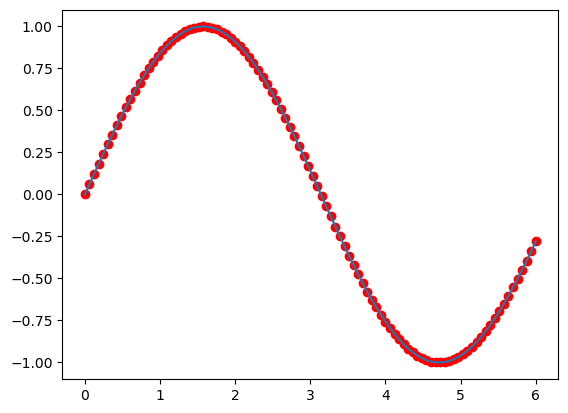

In [22]:
# import matplotlib.pyplot as plt (위 아래가 같은 식)
from matplotlib import pyplot as plt
plt.scatter(x, y, c='r') # 빨간색 점그래프
plt.plot(x, y) # 선 그래프
plt.show()

## 2.5 배열의 차원 변경
- reshpae(행수, 열수) : 변경된 배열 return(-1 가능)
- resize((행수, 열수)) : 배열을 차원 변경(-1 불가)
- ravel(), flatten() : 1 차원으로 변경된 배열 return
- T : 전치행렬로 변환된 배열을 return
- transpose() : 전치행렬로 변환

※ 실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨

In [27]:
t = np.random.random((2,5))
print (t)
print (t*10)

[[0.65047686 0.72393914 0.47508861 0.59666377 0.06696942]
 [0.07256214 0.19897603 0.151861   0.10010434 0.12929386]]
[[6.50476858 7.23939139 4.75088611 5.96663775 0.66969424]
 [0.72562138 1.98976026 1.51860997 1.00104345 1.29293865]]


In [26]:
# t * 10 요소별 연산
# round(t*10) : 스칼라 값을 반올림
a = np.round(t*10)
a

array([[ 7.,  3.,  6.,  3.,  4.],
       [ 1.,  2., 10.,  2.,  7.]])

In [30]:
a = a.astype(np.int16) # astype()을 이용한 요소별 타입 변환
a # 2행 5열

array([[ 7,  3,  6,  3,  4],
       [ 1,  2, 10,  2,  7]], dtype=int16)

In [33]:
a.reshape(5,-1) # -1이 주어지면 해당 차원의 크기가 자동 계산 a의 item이나 10이니까 5행으로 하면 2열로 자동 계산

array([[ 7,  3],
       [ 6,  3],
       [ 4,  1],
       [ 2, 10],
       [ 2,  7]], dtype=int16)

In [36]:
a = a.reshape(-1, 2) # a를 바꾸기 위해 a를 할당해야함.
a

array([[ 7,  3],
       [ 6,  3],
       [ 4,  1],
       [ 2, 10],
       [ 2,  7]], dtype=int16)

In [37]:
a.resize((2, 5))  # a를 바꿈
a.resize(2, 5)
a

array([[ 7,  3,  6,  3,  4],
       [ 1,  2, 10,  2,  7]], dtype=int16)

In [ ]:
# a.resize(-1) # resize는 마이너스를 사용할 수 없음. -1 사용불가

In [38]:
a.ravel()

array([ 7,  3,  6,  3,  4,  1,  2, 10,  2,  7], dtype=int16)

In [39]:
a.flatten()

array([ 7,  3,  6,  3,  4,  1,  2, 10,  2,  7], dtype=int16)

In [40]:
a

array([[ 7,  3,  6,  3,  4],
       [ 1,  2, 10,  2,  7]], dtype=int16)

In [41]:
a.T # a의 전치행렬(행과 열을 뒤바꾼 행렬 ex.0행 1열  -> 1행 0열)

array([[ 7,  1],
       [ 3,  2],
       [ 6, 10],
       [ 3,  2],
       [ 4,  7]], dtype=int16)

In [42]:
a.transpose() # a의 전치행렬

array([[ 7,  1],
       [ 3,  2],
       [ 6, 10],
       [ 3,  2],
       [ 4,  7]], dtype=int16)

In [43]:
a

array([[ 7,  3,  6,  3,  4],
       [ 1,  2, 10,  2,  7]], dtype=int16)

## 2.6 배열 인쇄

In [46]:
print(np.arange(10000).reshape(100,100)) # item 갯수가 1000개까지만 나옴

[[   0    1    2 ...   97   98   99]
 [ 100  101  102 ...  197  198  199]
 [ 200  201  202 ...  297  298  299]
 ...
 [9700 9701 9702 ... 9797 9798 9799]
 [9800 9801 9802 ... 9897 9898 9899]
 [9900 9901 9902 ... 9997 9998 9999]]


In [49]:
print(np.arange(10001)) # item 갯수가 10000개까지만 나와. 배열이 너무 크면 안나옴.

[    0     1     2 ...  9998  9999 10000]


In [52]:
np.arange(10000).reshape(100,100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

In [50]:
np.get_printoptions()['threshold'] # 출력되는 limit

1000

In [55]:
# 배열이 너무 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 모서리 부분만 출력
# 넘파이의 인쇄 옵션 변경(인쇄할 사이즈를 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 셋팅
np.set_printoptions(threshold=np.inf) # np.int : 무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [56]:
sys.maxsize

9223372036854775807

In [54]:
np.arange(10000).reshape(100,100)

array([[   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
          22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
          33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
          44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
          55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
          66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
          77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
          88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
          99],
       [ 100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
         111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
         122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
         133,  134,  135,  136,  137,  138,  139,  140,  141,  142,  143,
         144,  145,  14

In [5]:
# 커널을 재시작하거나 
import numpy as np
np.set_printoptions(threshold=1000)
np.arange(10000).reshape(100,100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

## 2.7 기본 연산 동작
### 1) 배열의 요소별 연산

In [6]:
a = np.array([10, 20, 30, 40], dtype=np.int8)
b = np.arange(4) # np.int32
print(a) # 배열을 print에 넣으면 array와 ,(콤마)가 안 나옴
print(b)

[10 20 30 40]
[0 1 2 3]


In [7]:
c = a+b # 요소별 + 연산 (dtype은 큰 거로, 정수와 실수 연산은 실수로)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [8]:
a*2

array([20, 40, 60, 80], dtype=int8)

In [9]:
a*b #요소별 연산시 dtype이 큰쪽인 int32

array([  0,  20,  60, 120])

In [10]:
a**b

array([    1,    20,   900, 64000], dtype=int32)

In [11]:
a < 40

array([ True,  True,  True, False])

In [16]:
# 인덱스의 인덱스
print(a[ [0,1,2,3] ])

[10 20 30 40]


In [15]:
# 인덱스 1출력, 2출력, 3출력
print(a [[1,2,3]]) # index를 list로 넣읗 것
print(a [[ True,  True,  True, False]] ) # boolean index
print(a [[0,2]]) 

[20 30 40]
[10 20 30]
[10 30]


In [18]:
# a 배열에서 40 미만인 데이터만 추출하려면  boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [19]:
# a배열에서 40미만인 데이터에 index를 추출
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2) 행렬의 곱 (@, dot함수) cf. *(요소별 곱)
- 2차원 배열은 행렬로 취급한다.
- pdf 18page

In [22]:
A = np.array([[1,1], [0,1]])
B = np.array([[2,0], [3,4]])
A,B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [25]:
print('요소별 곱 A*B =', A*B, sep="\n") 
print('행렬 곱 A@B =', A@B, sep="\n")
print("행렬 곱 A.dot(B) =", A.dot(B), sep"=\n")

SyntaxError: invalid syntax (1229997884.py, line 3)

In [33]:
# pdf 19
# ①
a = np.array([[1, 2], [3, 4]])
b = np.array([[-1, -1], [1, 1]])
print(a*b, b*a, sep="\n")

[[-1 -2]
 [ 3  4]]
[[-1 -2]
 [ 3  4]]


In [29]:
# pdf 19
# ②
a = np.array([[1, 2], [3, 4]])
b = np.array([[6], [7]])
print(a@b)
# m행 r열  @ r행 n열 = ? m행 n열
# b@a 에러 < ==  2x1 @2x2

[[20]
 [46]]


In [32]:
# pdf 19
# ③
a = np.array([[1, 2, 3], [3, 4, 1]])
b = np.array([[0, 0], [1, 1], [-1, 2]])
print(a@b) # 2x3 @ 3x2 ==> 2x2
print(b@a) #3x2 @ 2x3 ==> 3x3

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


In [34]:
# a@b !=(다르다) b@a
# a@단위 행렬 == 단위 행렬 @a ; 단위행렬에서느 행렬곱의 교환법칙이 성립
# 단위행렬은 정방행렬

A = np.array([[1, 0],
             [0, 1]]) # 2행 2열짜리 단위 행렬 (정방 행렬)
B = np.array([[2, 0],
             [3, 4]])
print('A@B =', A@B, sep='\n')

A@B =
[[2 0]
 [3 4]]


In [35]:
print('B@A =', B@A, sep='\n')

B@A =
[[2 0]
 [3 4]]


In [36]:
# 2행 2열 단위행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3) 복합 대입 연산자 사용(+=, -=, ....)
- 배열에서는  a+=b 는 a= a+b 와 다소 다르게 작동


In [40]:
a = np.ones((2,3), dtype='int8') # int8 범위 -128~127
b = np.random.random((2, 3)) # float64
print(a, b, sep="\n")

[[1 1 1]
 [1 1 1]]
[[0.53736153 0.19573619 0.21855588]
 [0.9483395  0.93813217 0.24162917]]


In [41]:
a += 5 # a = a+5
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [44]:
a += 255 # 공간이 부족하면 a에 오류
a

array([[521, 521, 521],
       [521, 521, 521]], dtype=int16)

In [43]:
a = a+255 # a+255를 요소별로 계산하며 새로운 a배열을 생성하여 할당
a

array([[266, 266, 266],
       [266, 266, 266]], dtype=int16)

In [45]:
b += a # b+a를 기존의 b에 넣는다.
b

array([[521.53736153, 521.19573619, 521.21855588],
       [521.9483395 , 521.93813217, 521.24162917]])

In [48]:
a += b # a+b(float64)를 기존의 a에 넣는다
a

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [49]:
# 스칼라 데이터에서는 문제되지 않음
x = 5
y = 5.7
x += y
x

10.7

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준변차)

In [52]:
a = np.array([[2, 2, 2, 3],
             [4, 3, 2, 1]])

In [54]:
print('전체 합 :', a.sum(), np.sum(a))
print('전체 최소값 :', a.min(), np.min(a))
print('전체 최대값 :', a.max(), np.max(a))
print('전체 평균 :', a.mean(), np.mean(a))
print('전체 분산 :', a.var(), np.var(a))
print('전체 표준편차 :', a.std(), np.std(a))

전체 합 : 19 19
전체 최소값 : 1 1
전체 최대값 : 4 4
전체 평균 : 2.375 2.375
전체 분산 : 0.734375 0.734375
전체 표준편차 : 0.8569568250501305 0.8569568250501305


In [55]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var()) # math.sqrt(스칼라값)

0.8569568250501305

### 5) 배열 축별 집계 

- 축별 sum, min, max, mean, var, std

    * (1차원일 때 axis 0=열
    * (2차원일 때 axis 0=행, axis1=열)
    * (3차원일 때 axis 0=면, axis1=행, axis2=열)

In [58]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [62]:
# axis = 1(1축)들의 합 : 행을 고정하고 1축(열들)의 합
print('a의 행별 합 :', a.sum(axis=1), np.sum(a, axis=1))

a의 행별 합 : [ 9 10] [ 9 10]


In [63]:
# axis = 1을 고정하고 0축 (행들)의 합
print('a의 열별 합 :', a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합 : [6 5 4 4] [6 5 4 4]


In [65]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) # 2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [67]:
b[0, 1, 2]

6

In [68]:
b.sum(), np.sum(b), b.min(), np.min(b)

(276, 276, 0, 0)

In [69]:
b.sum(axis=0) # 행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [70]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합 0, 0,0,+0,1,0,+,0,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [71]:
b.sum(axis=2) # 면과 행은 고정하고 열들의 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근
- np.add(A, B, C) : C = np.add(A, B)와 동일 / C = A+B와 동일 의미
- np.multipy(A, B, C) : C = np.multipy(A, B) / C= A*B와 동일 의미
- np.subtract(A, B, C) : C = np.subtract(A,B) / C =A,B와 동일 의미

In [72]:
a = np.array([1, 4])
b = np.array([3, 4])
c = np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([1.06099790e-313, 8.48798317e-314]))

In [73]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [75]:
np.add(a, b, c) # c=np.add(a,b), c = a + b
c = a + b
c

array([4, 8])

## 2.9 브로드케스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능


###  # 1차원 배열인 경우
- 참고 : pdf 26p.

In [77]:
a = np.array([1, 2, 3])
b = np.array([2])
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [79]:
a = np.array([1, 2, 3])
b = 2
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [80]:
a * b

array([2, 4, 6])

### # 2차원 배열인 경우의 브로드케스팅

In [81]:
a = np.array([[0,0,0], 
             [10, 10, 10],
             [20, 20, 20],
             [30, 30, 30]]) # 4x3 배열
b = np.array([1, 2, 3]) # 3열짜리 배열
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [82]:
a = np.array([[0,0,0], 
             [10, 10, 10],
             [20, 20, 20],
             [30, 30, 30]]) # 4x3 배열
b = np.array([[0],
              [1],
              [2],
              [3]]) # 4 x 1열짜리 배열
# 브로드케스팅 되서 아래와 같이 연산
# b = np.array([[0, 0, 0],
#               [1, 1, 1],
#               [2, 2, 2],
#               [3, 3, 3]])
a + b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

### # 브로드케스팅을 할 수 없는 예 (pdf 28p)

In [83]:
a = np.array([0, 10, 20, 30])
b = np.array([1, 2, 3])
a + b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [87]:
a

array([ 0, 10, 20, 30])

In [92]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A = a[:, np.newaxis] < = 가장 많이 사용되는 식
A = a.reshape(4, -1)
A = np.expand_dims(a, axis=1)
A
# np.array([[0],
#          [10],
#          [20],
#          [30]])

array([[ 0],
       [10],
       [20],
       [30]])

In [93]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 때 브로드케스팅 특성 이용, np.ix_함수 이용
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [94]:
ax, bx = np.ix_(a, b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax + bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열 합치기 / 분리하기

- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
- 슬라이싱
- 두배열을 합치는 함수
- r_, c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수

## 3.1 다차원 배열 인덱싱과 슬라이싱


In [96]:
b = np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [97]:
b[2, 1] # 없는 인덱싱시 에러

9

In [100]:
# 모든 행의 마지막 열 앞까지(종속 변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [101]:
b[..., :-1] # 모든 행의 경우, 선행축은 생략 불가능 ex.b[, :-1] 에러

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [102]:
# 0~2행까지 모든 열을 추출 (모든 열의 경우, 생략 가능 == 모든 열의 경우, 후행축은 생략가능)
b[0:3, :]
b[0:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [107]:
b[3:, 2:]
b[-2:, -2:]

array([[14, 15],
       [18, 19]])

## 3.2 두 배열을 쌓아 합치는 함수
- vstack(tup) : 아래 위로 추가하는 방식
- hatsck(tup) : 옆으로 추가하는 방식
- dstack(tup) : 마지막 축(열)을 쌓아 합치는 (차원 증가)

In [109]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack((c, d))
print('vstack으로 아래로 합치기 :', v, v.shape, sep='\n')
h = np.hstack((c, d))
print('hstack으로 옆으로 합치기 : ', h, h.shape, sep='\n')
d = np.dstack((c, d)) # .reshape(3,2)
print('dstack으로 depth로 합치기 : ', d, d.shape, sep='\n')

vstack으로 아래로 합치기 :
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기 : 
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기 : 
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [112]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [113]:
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [114]:
# 수직으로 합치기
np.vstack((a,b))

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [115]:
np.concatenate((a, b), axis=0) # axis = 0 이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [116]:
# 수평으로 합치기
np.hstack((a, b))

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [117]:
np.concatenate((a, b), axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [118]:
np.dstack((a, b))

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

- column_stack(tup) : 1차원 배열을 2차원 배열의 열 단위 합침
- row_stack(tup) : 행단위로 합침 == vstack()

In [120]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])
np.column_stack((a, b, c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [124]:
np.hstack((a[:, np.newaxis], b[:, np.newaxis], c[:, np.newaxis]))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [125]:
np.row_stack((a, b, c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [126]:
np.vstack((a, b, c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack(tup, axis=n) : axis속성에 따라 배열을 합침. axis는 음수차원 0행(첫번째 차원) / -1열(마지막축)

In [128]:
c = np.arange(24).reshape(2, 3, 4)
a,b = c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [129]:
np.stack((a, b), axis=0) # 2차원 배열끼리 stack하면 3차원으로 axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [130]:
np.stack((a, b), axis=1) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [131]:
np.stack((a, b), axis=2) # a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_(row), c_(column)
- 나열 객체

In [132]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])

In [133]:
np.r_[a, b, c] # 한행

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [135]:
np.r_[[a], [b], [c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [136]:
np.c_[a, b, c] # 컬럼 단위로 쌓아줌(c_ 와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [137]:
np.column_stack((a, b, c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit( ary, 정수나 백터) : 첫번째 축(axis0 - 2차원의 경우 가로축)을 따라 분활
- hsplit( ary, 정수나 백터) : 두번재 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split(ary, 정수나 백터, axis)
* 반드시 개수가 동일해야함.
----
- array_split(ary, 정수나 백터, axis) 
- **split()과 차이점은 나눠지지 않은 정수로도 사용 가능**

In [140]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [141]:
a_split = np.vsplit(a, 3) # 가로축(axis축)을 따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [142]:
a_split = np.vsplit(a, [2]) # 가로축(axis축)을 따라 2번째 index앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [143]:
np.hsplit(a, 2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [144]:
np.hsplit(a, [3]) # a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [145]:
np.hsplit(a, 3)

ValueError: array split does not result in an equal division

In [146]:
np.split(a, 3, axis=0) # 0축으로 분리(행으로 나눠라). 2차원에서의 vsplit(a, 3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [147]:
np.split(a, 2, axis=1) # 1 축으로 분리. 2차원에서의 hsplit(a, 2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [149]:
# np.split(a, 3, axis=1)
np.array_split(a, 3, axis=1) # 나눠지지 않는 정수 갯수를 알아서 나눔

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [150]:
np.split(a, [1, 2], axis=1) # 1번째 index, 2번째 index열을 기준으로 나눠

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절 복사와 뷰

## 4.1 할당

In [114]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 2570225975824 2570225975824
수정 후 a와 b주소 : 2570225975824 2570225978672
수정 후 a와 b 데이터 : 10 99


In [115]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [116]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 2570385638288)

In [117]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 2570385638288)

In [118]:
a is b

True

In [119]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [120]:
np.all(a==b) #np.all() array 배열 안의 모든 값이 True인지 여부

True

In [121]:
b.shape = (3, 4)

In [122]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2570385638288)

In [123]:
a.shape

(3, 4)

## 4.2 뷰(View): 얕은 복사

In [124]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [126]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [127]:
id(a), id(c)

(2570385641264, 2570382562512)

In [128]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [129]:
a is c

False

In [131]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [132]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [133]:
# 배열 복사본 c의 특정 요소만 변경
c[1, ::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [139]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
             [88, 71, 77, 77],
             [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [136]:
X = a[:, :-1]
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [137]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [138]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [140]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
             [88, 71, 77, 77],
             [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [ ]:
# 독립 변수 뽑기
# X = a[:, :-1] 얕은 복사(view 생성)
X = a[:, :-1].copy() # 깊은 복사
X = np.array(a[:, :-1], copy=True) #깊은 복사

In [141]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [142]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

# 5절. 고급인덱싱

## 5.1 인데스 배열로 인덱싱


In [163]:
a = np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [164]:
a[[0, 5, 9]]

array([ 0, 25, 81])

In [165]:
a[ [0, 1, 1, 5] ]

array([ 0,  1,  1, 25])

In [167]:
# 인덱싱하기 위한 값을 1차원 배열
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] # 결과는 인덱싱 배열(4열까지 1차원 배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [168]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0, 5],
                   [5, 8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [170]:
# 인덱스 배열을 이용한 a 수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [171]:
a[idx_ary] += 9 # 0번째, 5번째, (5번째), 8번째 / 복합대입연산자가 5번째는 한번만
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스
- 

In [172]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [175]:
# 각 열별 큰 값이 있는 index 행수
ind = data.argmax(axis=0) # 0행,1 행, 2행, 3행 중 가장 큰 값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [176]:
# 0열에서 제일 큰 행값, 1열에서 제일 큰 행값
data[ind[0], 0], data[ind[1],1]

(0.9893582466233818, 0.8414709848078965)

In [180]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [184]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [185]:
# 두 배열이 같은지 여부
np.all(data_col_max == data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱
- boolean index

In [186]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [187]:
a %2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [188]:
a[a%2==0] # 배열에서 원하는 조건의 item만 추출

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [189]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [190]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절 선형대수학
- 2차원 배열을 행렬로 취급
    * 행렬곱 : @, np.dot()
    * 역행렬 : np.linalg.inv(X) 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬로 나옴
    * 전치행렬 : X.T, X.transpose() 행과 열을 바꾼다.
    * 단위행렬 : np.eye(n) n행 n열 단위행렬
    

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
     width = "200"
     style = "float:left">